# Early Model Testing

Plan and runnable steps for the Early Model Testing phase (16 Mar → 19 Apr).

Sections:
- Initial data validation and exploratory analysis
- Statistical anomaly detection & rule-based baselines
- Simple ML models (unsupervised + supervised)

This notebook assumes the dataset files are in `../data/` and were generated by `01_data_generation.ipynb`.

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
sns.set(style='whitegrid')
%matplotlib inline


## Paths and data load
Make sure `data/aml_synthetic_data.csv`, `data/aml_nodes.csv`, and `data/aml_edges.csv` exist before running.

In [2]:
DATA_DIR = os.path.join('..', 'data')
TX_FILE = os.path.join(DATA_DIR, 'aml_synthetic_data.csv')
NODES_FILE = os.path.join(DATA_DIR, 'aml_nodes.csv')
EDGES_FILE = os.path.join(DATA_DIR, 'aml_edges.csv')

print('Checking files...')
for f in [TX_FILE, NODES_FILE, EDGES_FILE]:
    print(f, '->', os.path.exists(f))

# Load (lazy: smaller preview if large)
tx_df = pd.read_csv(TX_FILE, parse_dates=['timestamp'])
node_df = pd.read_csv(NODES_FILE)
edge_df = pd.read_csv(EDGES_FILE, parse_dates=['timestamp'])

print('\nTx shape:', tx_df.shape)
print('Node shape:', node_df.shape)
print('Edge shape:', edge_df.shape)


Checking files...
../data/aml_synthetic_data.csv -> True
../data/aml_nodes.csv -> True
../data/aml_edges.csv -> True

Tx shape: (29513, 32)
Node shape: (446, 22)
Edge shape: (29513, 17)


## Initial data validation and exploratory analysis
Basic validation checks and exploratory plots to establish dataset quality and distributions.

In [3]:
# Quick data validation

display(tx_df.head())
print('\nDtypes and missing values:')
print(tx_df.dtypes)
print('\nMissing counts (top 30):')
print(tx_df.isna().sum().sort_values(ascending=False).head(30))

# Unique counts
print('\nUnique accounts:', pd.unique(tx_df[['from_account','to_account']].values.ravel()).size)
print('Unique payment formats:', tx_df['payment_format'].nunique())
print('Currencies:', tx_df['paying_currency'].unique())


,transaction_id,player_id,from_account,to_account,from_bank,to_bank,timestamp,amount_paid,paying_currency,amount_received,...,game_result,device,ip_address,location,time_since_last_action,bet_direction,topology_type,money_launderer,player_label,is_suspicious
0,TX_0026836,SUSP_BOT_0001,SOURCE,SUSP_BOT_0001,EXTERNAL,BANK_00C,2025-02-27 16:18:20.414639,4800.0,Canadian Dollar,36977.78,...,NaN,PC,10.239.82.77,VPN,NaN,NaN,NaN,True,Suspicious_Bot,True
1,TX_0026837,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_00C,PLATFORM_BANK,2025-02-27 16:19:19.201700,50.0,Mexican Peso,3.95,...,Lose,PC,10.186.215.206,Macau,1.5,player,NaN,True,Suspicious_Bot,True
2,TX_0026838,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_016,PLATFORM_BANK,2025-02-27 16:19:23.138456,50.0,Yuan,5.46,...,Lose,Android,10.154.59.193,US,1.5,player,NaN,True,Suspicious_Bot,True
3,TX_0026839,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_018,PLATFORM_BANK,2025-02-27 16:19:22.872528,50.0,Yuan,9.32,...,Win,Android,10.163.154.197,Macau,1.5,player,NaN,True,Suspicious_Bot,True
4,TX_0026840,SUSP_BOT_0001,SUSP_BOT_0001,PLATFORM,BANK_012,PLATFORM_BANK,2025-02-27 16:19:26.459201,50.0,Ruble,5.78,...,Lose,Android,10.224.113.140,Macau,1.5,player,NaN,True,Suspicious_Bot,True



Dtypes and missing values:
transaction_id                    object
player_id                         object
from_account                      object
to_account                        object
from_bank                         object
to_bank                           object
timestamp                 datetime64[ns]
amount_paid                      float64
paying_currency                   object
amount_received                  float64
receiving_currency                object
payment_format                    object
session_id                        object
amount                           float64
currency                          object
channel                           object
action_type                       object
bet_amount                       float64
balance_before                   float64
balance_after                    float64
deposit_amount                   float64
withdraw_amount                  float64
game_result                       object
device                       

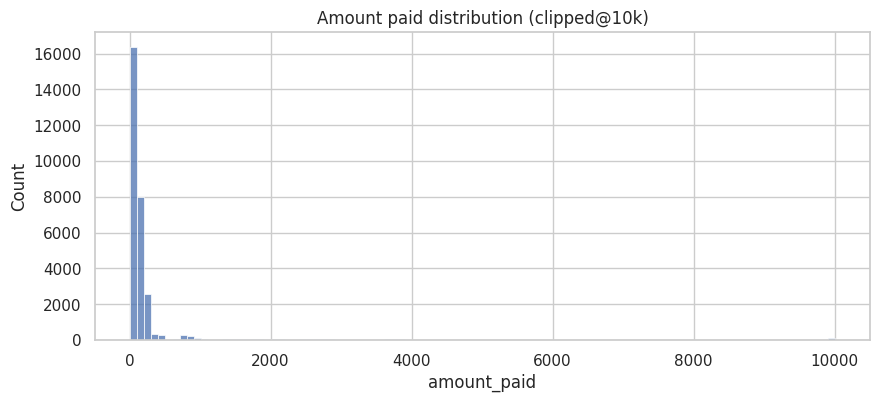

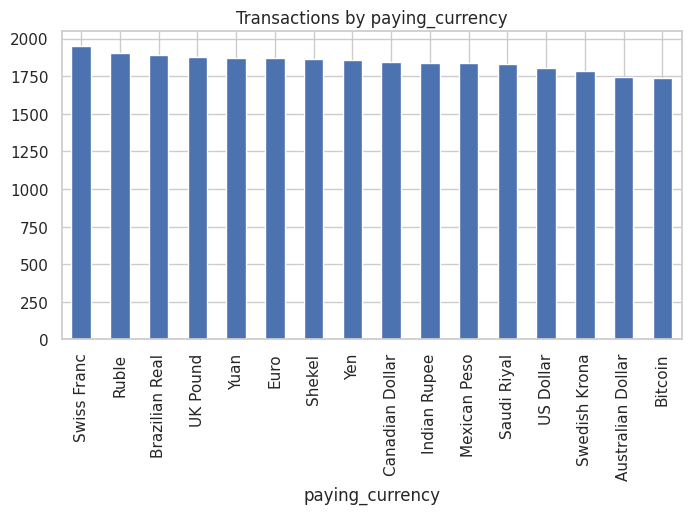

In [4]:
# Amount distribution
plt.figure(figsize=(10,4))
sns.histplot(tx_df['amount_paid'].clip(upper=10000), bins=100, kde=False)
plt.title('Amount paid distribution (clipped@10k)')
plt.show()

# Per-currency counts
plt.figure(figsize=(8,4))
tx_df['paying_currency'].value_counts().plot(kind='bar')
plt.title('Transactions by paying_currency')
plt.show()

Top 10 accounts by amount_received:
to_account
PLATFORM              3.131173e+11
SUSP_RAPID_0003       1.079190e+11
SINK                  6.899186e+10
SUSP_RAPID_0001       6.176213e+10
SUSP_CRYPTO_0005      5.974801e+10
TOPO_GS_0001_SRC03    3.941817e+10
TOPO_FO_0004_ORIG     3.812628e+10
TOPO_CYC_0002_N03     3.791023e+10
TOPO_FI_0000_COLL     2.563428e+10
TOPO_BI_0003_L02      1.973643e+10
Name: amount_received, dtype: float64

Top 10 senders by amount_paid:
from_account
SOURCE              3.615655e+06
SUSP_SPIKE_0000     7.362106e+04
SUSP_SPIKE_0009     7.013719e+04
SUSP_SPIKE_0006     6.770301e+04
SUSP_STRUCT_0007    6.541518e+04
SUSP_SPIKE_0004     6.386273e+04
SUSP_STRUCT_0009    6.180402e+04
SUSP_BOT_0000       5.751991e+04
SUSP_SPIKE_0001     5.603734e+04
NORM_B_0027         5.393166e+04
Name: amount_paid, dtype: float64


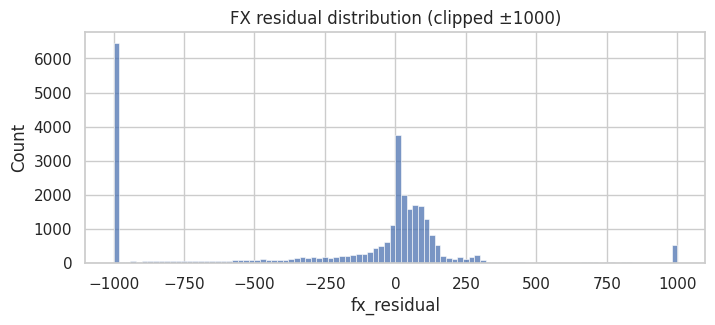

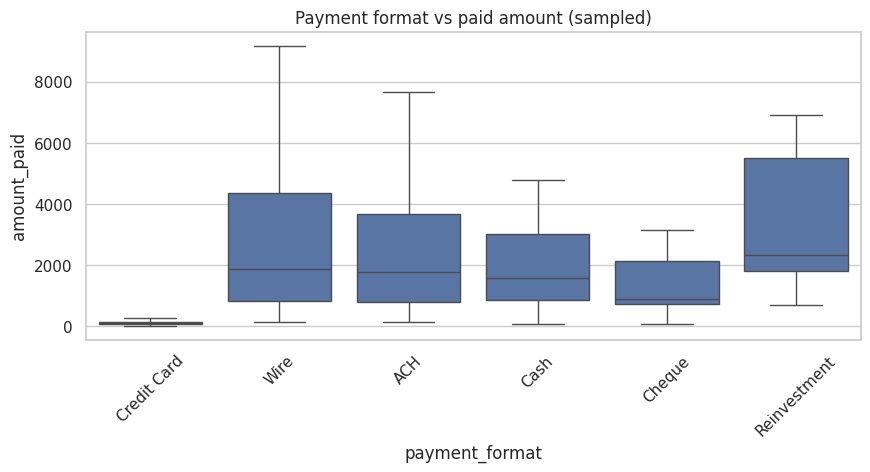

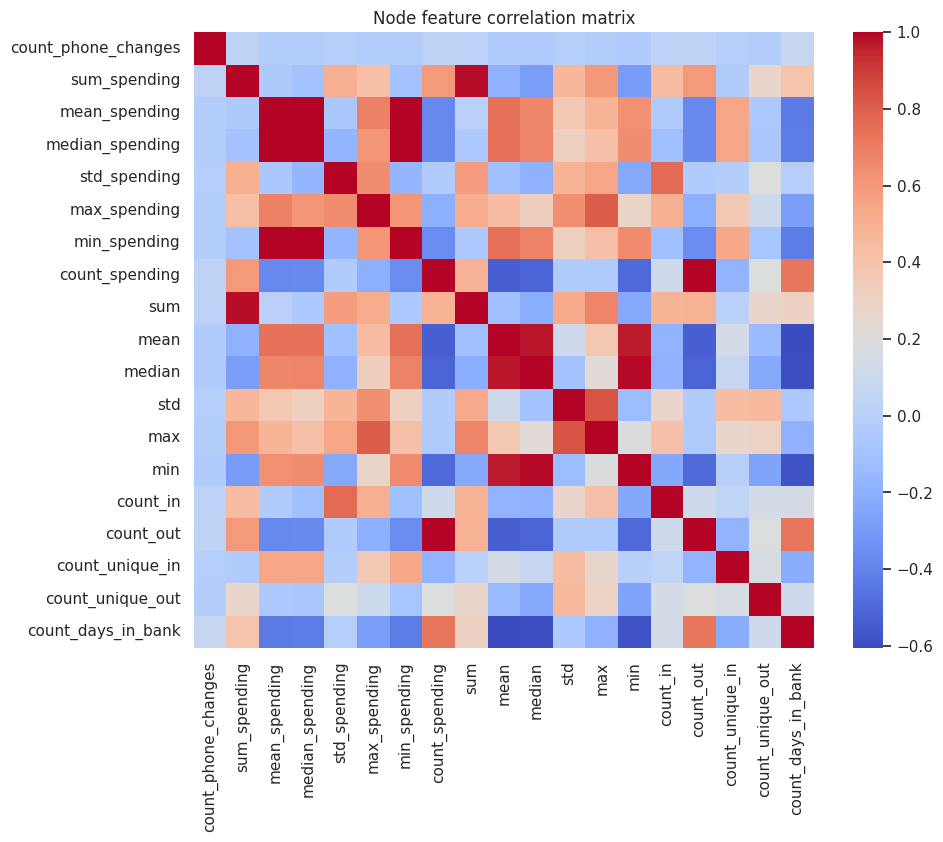


Top 10 accounts by transaction count (from+to):
PLATFORM       27269.0
SOURCE          1510.0
NORM_B_0016      432.0
NORM_B_0032      428.0
NORM_B_0007      413.0
NORM_B_0027      387.0
SINK             386.0
NORM_B_0017      374.0
NORM_B_0036      368.0
NORM_B_0013      368.0
dtype: float64


In [5]:
# --- Expanded EDA: top accounts, fx residuals, payment format analysis ---
# Top accounts by received amount
top_received = tx_df.groupby('to_account')['amount_received'].sum().sort_values(ascending=False).head(10)
print('Top 10 accounts by amount_received:')
print(top_received)

# Top senders by total paid
top_senders = tx_df.groupby('from_account')['amount_paid'].sum().sort_values(ascending=False).head(10)
print('\nTop 10 senders by amount_paid:')
print(top_senders)

# FX residual (sender - receiver) distribution
tx_df['fx_residual'] = tx_df['amount_paid'] - tx_df['amount_received']
plt.figure(figsize=(8,3))
sns.histplot(tx_df['fx_residual'].clip(-1000,1000), bins=100)
plt.title('FX residual distribution (clipped ±1000)')
plt.show()

# Payment format vs amount boxplot (show median/spread)
plt.figure(figsize=(10,4))
sns.boxplot(x='payment_format', y='amount_paid', data=tx_df.sample(min(5000, len(tx_df))), showfliers=False)
plt.xticks(rotation=45)
plt.title('Payment format vs paid amount (sampled)')
plt.show()

# Correlation heatmap for node features (if present)
try:
    num_cols = node_df.select_dtypes(include=[np.number]).columns
    plt.figure(figsize=(10,8))
    sns.heatmap(node_df[num_cols].corr(), annot=False, cmap='coolwarm')
    plt.title('Node feature correlation matrix')
    plt.show()
except Exception:
    print('Node feature correlation not available')

# Transaction counts per account (top 10)
acct_counts = pd.Series(pd.unique(tx_df[['from_account','to_account']].values.ravel())).value_counts() if False else None
print('\nTop 10 accounts by transaction count (from+to):')
combined_counts = pd.concat([
    tx_df['from_account'].value_counts(),
    tx_df['to_account'].value_counts()
], axis=1).fillna(0).sum(axis=1).sort_values(ascending=False).head(10)
print(combined_counts)


Timestamp range: 2025-02-27 16:18:20.414639 -> 2025-03-30 14:22:41.485157


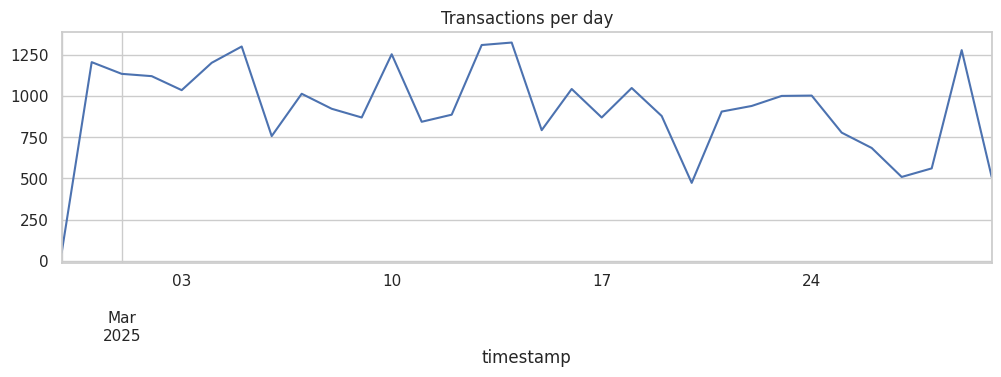

In [6]:
# Temporal checks
print('Timestamp range:', tx_df['timestamp'].min(), '->', tx_df['timestamp'].max())

per_day = tx_df.set_index('timestamp').resample('D').size()
plt.figure(figsize=(12,3))
per_day.plot()
plt.title('Transactions per day')
plt.show()

## Statistical anomaly detection & rule-based baselines
Create simple rules and statistical detectors to produce baseline alerts and measure overlap with labeled laundering accounts.

### Rule-based results analysis

- We implemented a basic set of rules (High amount, Cash payments) and an extended set including Structuring, Rapid in/out and High-outgoing-ratio.
- Below we discuss the precision/recall numbers and likely reasons for behaviour:
  - High precision with low recall typically means the rule is conservative (few false positives but misses many true SARs).
  - Structuring and rapid in/out aim to increase recall by capturing repeated small deposits and short-cycle laundering.
  - High outgoing ratio picks up pull-through behaviour where funds immediately leave an account.

Interpretation steps after the metrics: examine which rules trigger most true positives, inspect false positives manually (top examples), and adjust thresholds (e.g., `min_count_struct`, `small_amt_thr`) to trade precision vs recall.


### Experiment 1 — Basic rules

This first experiment uses two simple, conservative rules as a baseline:

- **Rule A — High single payment:** flag transactions where `amount_paid` is above the 99.5th percentile.
- **Rule B — Cash payments:** flag transactions where `payment_format` contains `Cash`.

We evaluate these rules for precision and recall against the `money_launderer` label. Code follows in the next cell.

### Experiment 2 — Extended rules

This second experiment extends the baseline with additional rules designed to capture typical laundering tactics:

- **Rule C — Structuring:** multiple small deposits to the same account within a short window (7 days).
- **Rule D — Rapid in/out:** a deposit followed by a withdrawal from the same account within 1 day.
- **Rule E — High outgoing ratio:** accounts that send out most of what they receive (>90%), indicative of immediate pull-through.

We combine the baseline and extended rules and evaluate a combined alert signal (`rule_alert_v2`). The implementation and performance output follow in the code cell above.

In [7]:
# Implement multiple rule-based detectors
# Rule A: High amount
high_amt_thr = tx_df['amount_paid'].quantile(0.995)
tx_df['rule_high_amount'] = tx_df['amount_paid'] > high_amt_thr

# Rule B: Cash payments
tx_df['rule_cash'] = tx_df['payment_format'].str.contains('Cash', na=False)

# Rule C: Structuring — many small deposits within 7 days
small_amt_thr = tx_df['amount_paid'].quantile(0.25)  # e.g. small deposits under 25th pct
min_count_struct = 5
is_deposit = tx_df['action_type'] == 'deposit'

deposits = tx_df[is_deposit].sort_values(['to_account','timestamp']).copy()
struct_idx = []
for acct, grp in deposits.groupby('to_account'):
    times = grp['timestamp'].values
    amounts = grp['amount_paid'].values
    flags = []
    for i, t in enumerate(times):
        window_start = t - np.timedelta64(7, 'D')
        mask = (times >= window_start) & (times <= t) & (amounts <= small_amt_thr)
        flags.append(mask.sum() >= min_count_struct)
    struct_idx.extend(list(zip(grp.index, flags)))

struct_flag = pd.Series(False, index=tx_df.index)
for idx, flag in struct_idx:
    struct_flag.at[idx] = flag

tx_df['rule_structuring'] = struct_flag

# Rule D: Rapid in/out — a deposit followed by a withdrawal within 1 day for same account
withdrawals = tx_df[tx_df['action_type']=='withdrawal'].sort_values(['from_account','timestamp'])
rapid_flag = pd.Series(False, index=tx_df.index)
for acct, grp in tx_df[tx_df['action_type']=='deposit'].groupby('to_account'):
    w = withdrawals[withdrawals['from_account']==acct]
    if w.empty:
        continue
    dep_times = grp['timestamp'].values
    for idx, t in zip(grp.index, dep_times):
        # any withdrawal within 1 day after deposit?
        window_end = t + np.timedelta64(1, 'D')
        if ((w['timestamp'] >= t) & (w['timestamp'] <= window_end)).any():
            rapid_flag.at[idx] = True

# Map deposit rapid flags to the same account transactions (we mark the deposit rows)
tx_df['rule_rapid_inout'] = rapid_flag

# Rule E: High outgoing ratio per account (compute on aggregate)
acct_sums = tx_df.groupby('from_account')['amount_paid'].sum().rename('sent').to_frame()
acct_recv = tx_df.groupby('to_account')['amount_received'].sum().rename('recv').to_frame()
acct_tot = acct_sums.join(acct_recv, how='outer').fillna(0)
acct_tot['out_ratio'] = acct_tot['sent'] / (acct_tot['recv'].replace({0: np.nan}))
high_out_accts = set(acct_tot[acct_tot['out_ratio'] > 0.9].index)

tx_df['rule_high_out_ratio'] = tx_df['from_account'].isin(high_out_accts)

# Combine rules into two alert variants
tx_df['rule_alert_basic'] = tx_df[['rule_high_amount','rule_cash']].any(axis=1)
tx_df['rule_alert_v2'] = tx_df[['rule_high_amount','rule_cash','rule_structuring','rule_rapid_inout','rule_high_out_ratio']].any(axis=1)

# Evaluate both
y_true = tx_df['money_launderer'].fillna(False).astype(bool)
for name in ['rule_alert_basic','rule_alert_v2']:
    y_pred = tx_df[name]
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    print(f"{name} — precision: {p:.3f}  recall: {r:.3f}  f1: {f:.3f}")


rule_alert_basic — precision: 0.618  recall: 0.064  f1: 0.117
rule_alert_v2 — precision: 0.318  recall: 0.421  f1: 0.362


In [8]:
# Prepare transaction-level features and labels (leakage-safe)
import os
from sklearn.model_selection import GroupShuffleSplit

rel_path = os.path.join('data', 'aml_synthetic_data.csv')
abs_path = '/home/rachel/ltgame/aml/data/aml_synthetic_data.csv'
if os.path.exists(rel_path):
    tx_ml = pd.read_csv(rel_path)
elif os.path.exists(abs_path):
    tx_ml = pd.read_csv(abs_path)
else:
    raise FileNotFoundError('aml_synthetic_data.csv not found')

label_col = 'money_launderer' if 'money_launderer' in tx_ml.columns else 'label'
if label_col not in tx_ml.columns:
    raise RuntimeError('No label column found in transaction dataset')

tx_ml[label_col] = tx_ml[label_col].astype(int)

feature_cols = [
    'amount_paid','amount_received','amount',
    'paying_currency','receiving_currency','payment_format',
    'from_bank','to_bank','channel','action_type','topology_type'
]
feature_cols = [c for c in feature_cols if c in tx_ml.columns]

work = tx_ml[feature_cols + [label_col] + (["timestamp"] if 'timestamp' in tx_ml.columns else []) + (["from_account"] if 'from_account' in tx_ml.columns else []) + (["player_id"] if 'player_id' in tx_ml.columns else [])].copy()

# Time-based split preferred
if 'timestamp' in work.columns:
    work['timestamp'] = pd.to_datetime(work['timestamp'])
    cutoff = work['timestamp'].quantile(0.7)
    train_df = work[work['timestamp'] <= cutoff].copy()
    test_df = work[work['timestamp'] > cutoff].copy()
    split_mode = 'time'
else:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    groups = work['from_account'] if 'from_account' in work.columns else work['player_id']
    tr_idx, te_idx = next(gss.split(work, groups=groups))
    train_df, test_df = work.iloc[tr_idx].copy(), work.iloc[te_idx].copy()
    split_mode = 'group'

num_feats = [c for c in ['amount_paid','amount_received','amount'] if c in work.columns]
cat_feats = [c for c in ['paying_currency','receiving_currency','payment_format','from_bank','to_bank','channel','action_type','topology_type'] if c in work.columns]

def build_features(df, train_columns=None):
    X_num = df[num_feats].fillna(0).copy()
    X_cat = pd.get_dummies(df[cat_feats].fillna('NA').astype(str), drop_first=True)
    X = pd.concat([X_num, X_cat], axis=1)
    if train_columns is not None:
        X = X.reindex(columns=train_columns, fill_value=0)
    return X

X_train = build_features(train_df)
X_test = build_features(test_df, train_columns=X_train.columns)
y_train = train_df[label_col]
y_test = test_df[label_col]

print(f'Split mode: {split_mode}')
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Positive rate train/test:', round(y_train.mean(), 4), round(y_test.mean(), 4))

Split mode: time
Train shape: (20659, 103) Test shape: (8854, 103)
Positive rate train/test: 0.2777 0.0054


## Simple ML Models (Leakage-safe)

This section trains baseline models using **transaction-level features only** (amounts, currencies, payment format, channel, banks, action type, topology type).

To avoid leakage, we do:
- **Time-based split** on `timestamp` (train: earlier transactions, test: later transactions), or group split fallback.
- **No node-level aggregated features** from `aml_nodes.csv`.
- **Train-only encoding alignment** for categorical variables.

In [9]:
# Supervised baseline: RandomForest (transaction-level)
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
y_prob = rf.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.5).astype(int)
p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
auc = roc_auc_score(y_test, y_prob)
print('RF — precision: %.3f  recall: %.3f  f1: %.3f  AUC: %.3f' % (p, r, f, auc))

RF — precision: 0.084  recall: 0.771  f1: 0.151  AUC: 0.919


### Isolation Forest 


In [10]:
# Unsupervised baselines on transaction-level features
# IsolationForest
iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
iso.fit(X_train)
iso_scores = -iso.decision_function(X_test)
auc_iso = roc_auc_score(y_test, iso_scores)
print('IsolationForest AUC (transaction-level):', round(auc_iso, 3))

# LOF with novelty mode to score test after training on train
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02, novelty=True)
lof.fit(X_train.values)
lof_scores = -lof.decision_function(X_test.values)
auc_lof = roc_auc_score(y_test, lof_scores)
print('LOF AUC (transaction-level):', round(auc_lof, 3))

IsolationForest AUC (transaction-level): 0.872
LOF AUC (transaction-level): 0.727


### Logistic Regression 

In [11]:
# Logistic Regression (transaction-level)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)
y_prob_lr = lr.predict_proba(X_test_s)[:,1]
y_pred_lr = (y_prob_lr > 0.5).astype(int)
p, r, f, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='binary', zero_division=0)
auc_lr = roc_auc_score(y_test, y_prob_lr)
print('LogisticRegression — precision: %.3f  recall: %.3f  f1: %.3f  AUC: %.3f' % (p, r, f, auc_lr))



LogisticRegression — precision: 0.031  recall: 0.604  f1: 0.059  AUC: 0.839


In [12]:
# Feature importances (RF and GB)
try:
    importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    # importances_gb = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print('\nTop RF features:\n', importances_rf.head(10))
    # print('\nTop GB features:\n', importances_gb.head(10))
except Exception as e:
    print('Could not compute/import feature importances:', e)


Top RF features:
 amount_paid                       0.264628
amount                            0.263236
amount_received                   0.112135
channel_Platform                  0.008311
to_bank_PLATFORM_BANK             0.007572
paying_currency_Brazilian Real    0.006889
paying_currency_Shekel            0.006761
receiving_currency_Yuan           0.006655
receiving_currency_Shekel         0.006580
receiving_currency_Saudi Riyal    0.006566
dtype: float64


### Gradient Boosting


In [13]:
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_prob_gb = gb.predict_proba(X_test)[:,1]
y_pred_gb = (y_prob_gb > 0.5).astype(int)
p, r, f, _ = precision_recall_fscore_support(y_test, y_pred_gb, average='binary', zero_division=0)
auc_gb = roc_auc_score(y_test, y_prob_gb)
print('GradientBoosting — precision: %.3f  recall: %.3f  f1: %.3f  AUC: %.3f' % (p, r, f, auc_gb))

# Feature importances (RF and GB)
try:
    # importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    importances_gb = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    # print('\nTop RF features:\n', importances_rf.head(10))
    print('\nTop GB features:\n', importances_gb.head(10))
except Exception as e:
    print('Could not compute/import feature importances:', e)

GradientBoosting — precision: 0.100  recall: 0.750  f1: 0.176  AUC: 0.946

Top GB features:
 amount_paid               0.469914
amount                    0.447507
action_type_deposit       0.024097
from_bank_EXTERNAL        0.009365
amount_received           0.007456
to_bank_EXTERNAL          0.006554
to_bank_PLATFORM_BANK     0.005543
action_type_withdrawal    0.003631
channel_Platform          0.003300
action_type_transfer      0.002071
dtype: float64


## Next steps and notes
- The notebook provides a lightweight baseline pipeline: validation, simple rules, unsupervised detectors, and a supervised baseline.
- Improve rule-based logic (per-account rolling windows) and tune contamination/thresholds for unsupervised models.
- Add feature engineering (temporal aggregates, payment-format encoding, currency conversion residuals).
- For reproducibility: run the notebook end-to-end with `jupyter nbconvert --to notebook --execute notebooks/02_early_model_testing.ipynb --inplace`.